# Exploratory Data Analysis (EDA)

## Objective

The objective of this analysis is to explore the Xente transaction dataset, assess data quality, understand customer transaction behavior, identify patterns and anomalies, and generate insights that will guide feature engineering and credit risk modeling.

## Analysis Goals

* Understand the structure and characteristics of the dataset.
* Identify missing values and potential data quality issues.
* Analyze the distribution of numerical and categorical variables.
* Detect outliers and unusual transaction behavior.
* Explore relationships between variables.
* Investigate temporal transaction patterns.
* Generate hypotheses for customer risk profiling and feature engineering.

## Expected Outcome

The findings from this analysis will be used to:

1. Design customer-level aggregate features.
2. Create Recency-Frequency-Monetary (RFM) metrics.
3. Construct a proxy target variable for credit risk.
4. Build a robust preprocessing pipeline for downstream machine learning models.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Load Data

In [2]:
try:
    df = pd.read_csv("../data/raw/data.csv")
    print(f"Dataset loaded successfully: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Verify file path.")
except Exception as e:
    print(f"Unexpected error: {e}")

df.head()

Dataset loaded successfully: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


## Dataset Overview

This section examines the size, structure, and data types of the dataset to understand the available information and identify any immediate data quality concerns.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionId,95662,95662,TransactionId_76871,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,95662,94809,BatchId_67019,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,95662,3633,AccountId_4841,30893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,95662,3627,SubscriptionId_3829,32630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,95662,3742,CustomerId_7343,4091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,95662,1,UGX,95662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,95662.0,NaN,NaN,NaN,256.0,0.0,256.0,256.0,256.0,256.0,256.0
ProviderId,95662,6,ProviderId_4,38189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,95662,23,ProductId_6,32635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,95662,9,financial_services,45405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Value Analysis

Missing values can negatively impact model performance and feature engineering. This section evaluates the extent and distribution of missing data to determine appropriate treatment strategies.

In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [6]:
(df.isnull().mean()*100).sort_values(ascending=False)

TransactionId           0.0
BatchId                 0.0
AccountId               0.0
SubscriptionId          0.0
CustomerId              0.0
CurrencyCode            0.0
CountryCode             0.0
ProviderId              0.0
ProductId               0.0
ProductCategory         0.0
ChannelId               0.0
Amount                  0.0
Value                   0.0
TransactionStartTime    0.0
PricingStrategy         0.0
FraudResult             0.0
dtype: float64

No missing values were detected in any feature.

## Summary Statistics

In [8]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


The dataset contains 95,662 transaction records and 16 variables describing customer identities, products, transaction amounts, channels, and fraud outcomes. Data quality appears high, as all columns contain complete observations with no missing values. Most variables are categorical, indicating that feature engineering and encoding will play an important role in model development.

## Numerical Feature Distribution

Understanding the distribution of numerical variables helps identify skewness, unusual patterns, and potential transformations required before modeling.

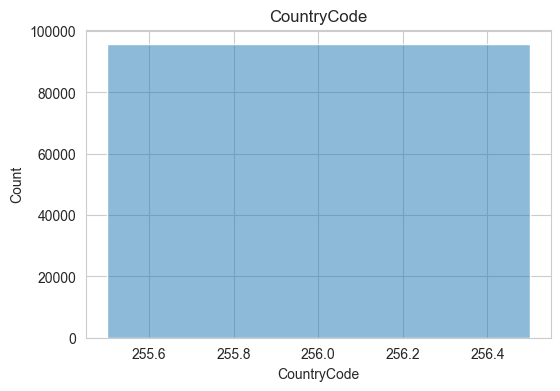

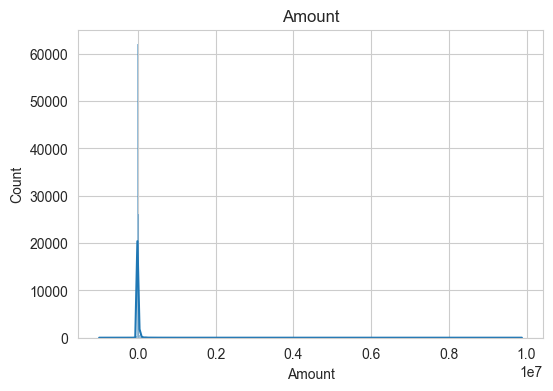

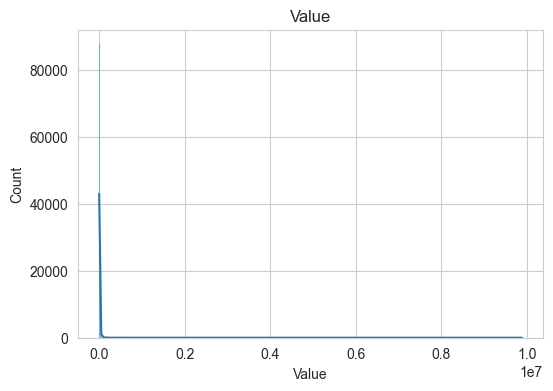

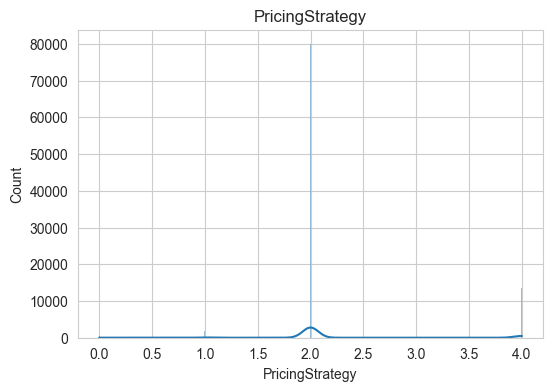

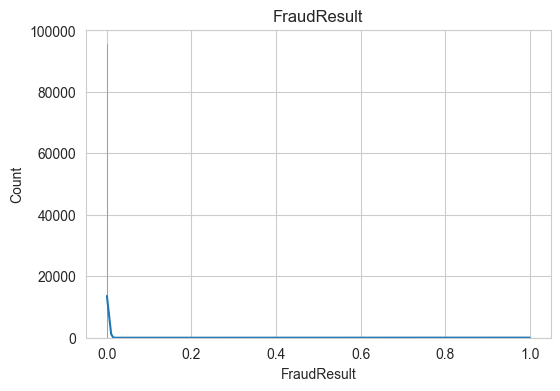

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

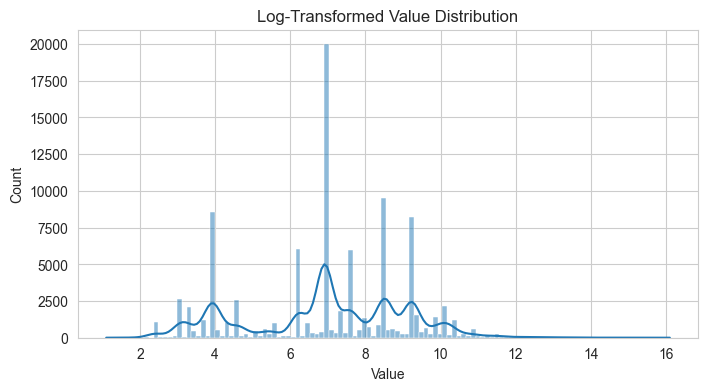

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df["Value"]), kde=True)
plt.title("Log-Transformed Value Distribution")
plt.show()

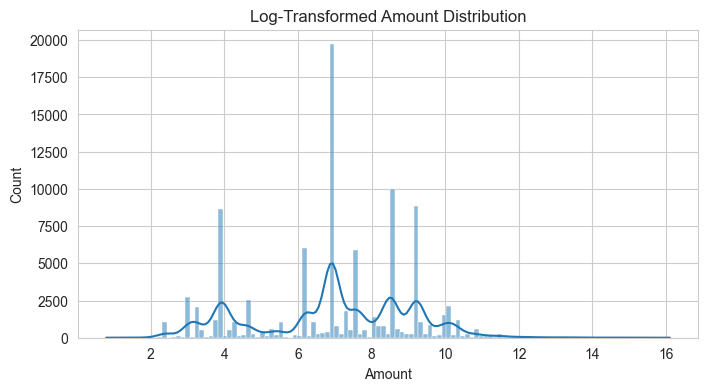

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(np.abs(df["Amount"])), kde=True)
plt.title("Log-Transformed Amount Distribution")
plt.show()

Transaction amounts are heavily right-skewed, with most transactions concentrated at lower values and a small number of extremely large transactions creating a long tail. This suggests the presence of significant outliers and indicates that scaling or logarithmic transformation may improve downstream model performance.

## Outlier Detection

Outliers may represent fraud, abnormal customer behavior, or data quality issues. This section identifies extreme observations that may influence model performance.

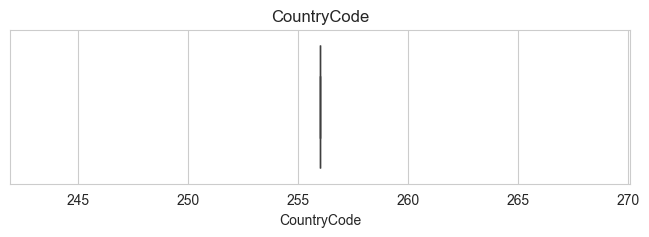

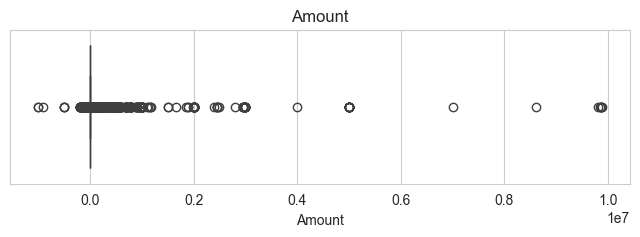

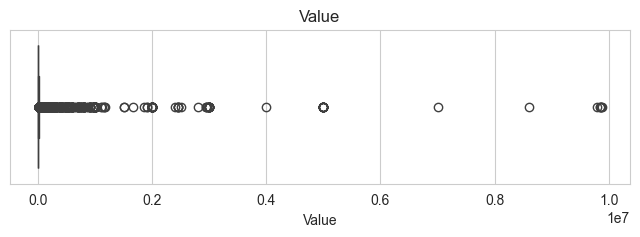

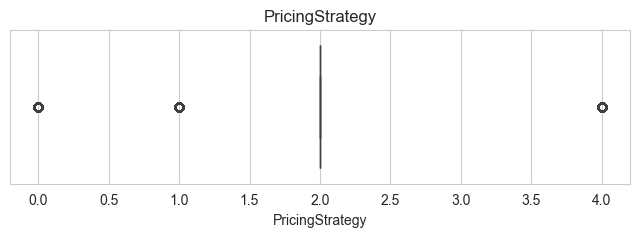

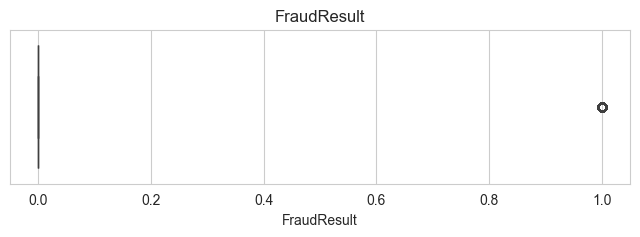

In [10]:
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Interpretation

The boxplot reveals the presence of several observations outside the interquartile range.

Key observations:

- Number of outliers.
- Magnitude of extreme values.
- Potential influence on model training.

Implication:
Further investigation is required to determine whether these values represent legitimate customer behavior or noise.

## Categorical Feature Distribution

This section examines the frequency distribution of categorical variables to identify dominant categories, rare values, and potential encoding considerations.

In [11]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

C:\Users\sumex\AppData\Local\Temp\ipykernel_6876\2960911289.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

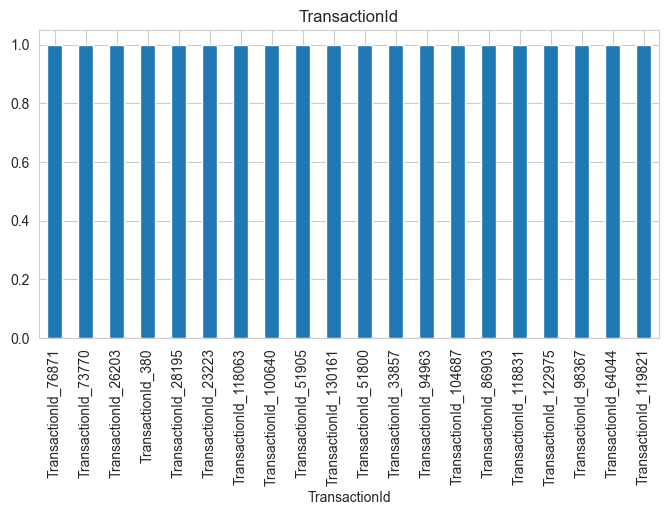

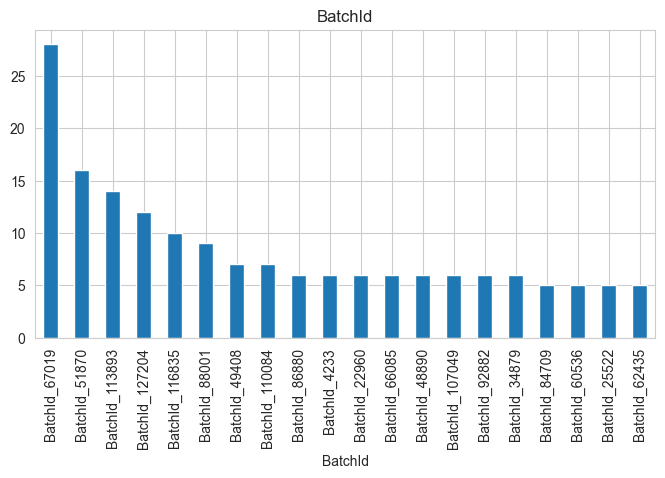

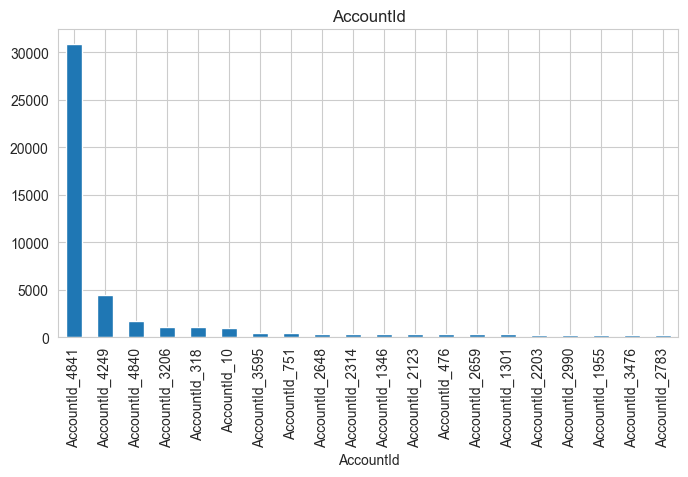

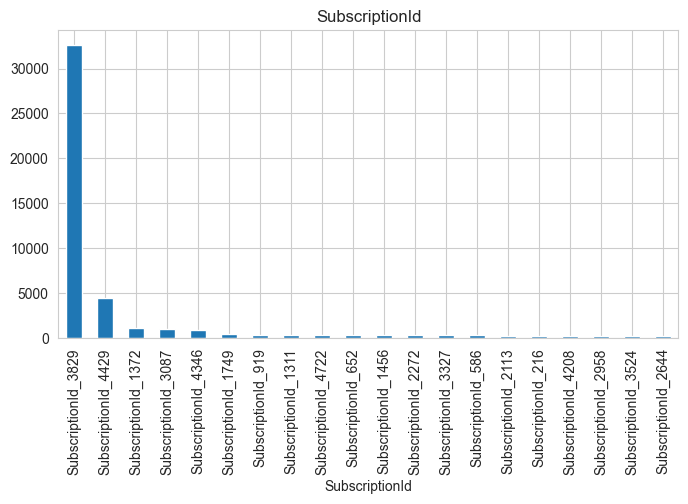

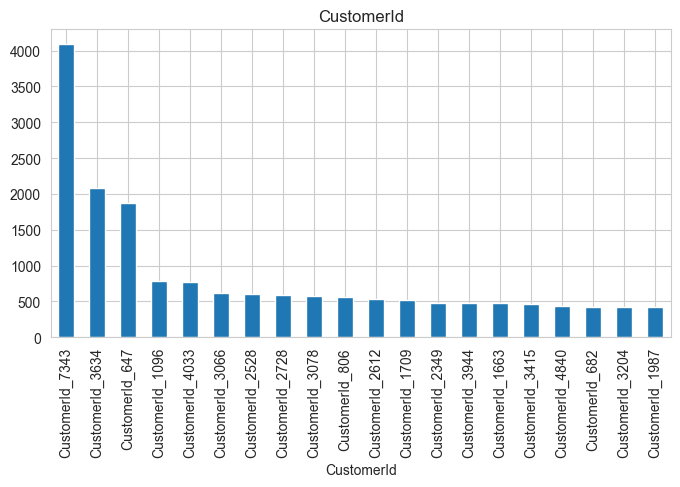

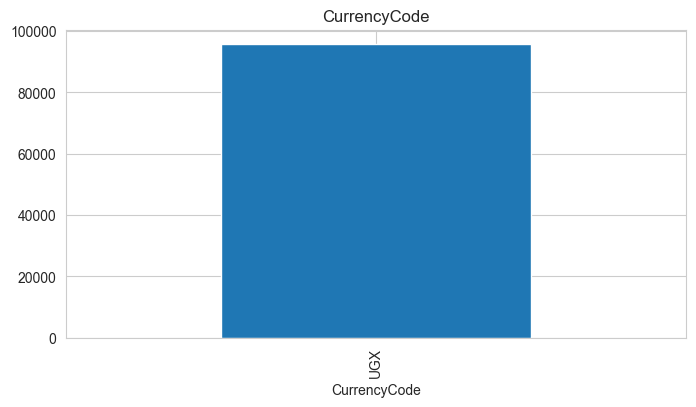

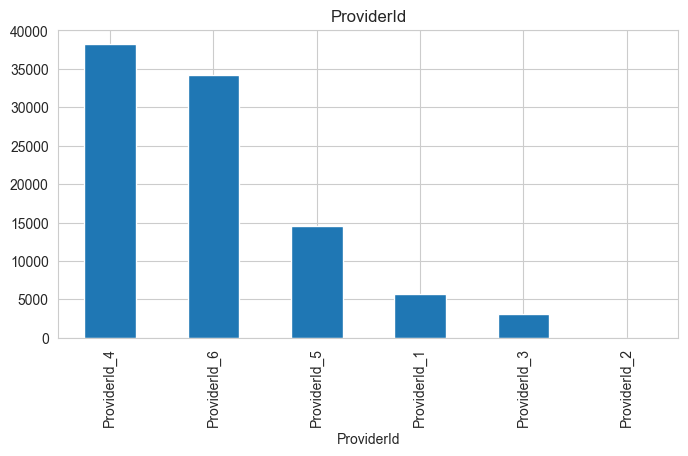

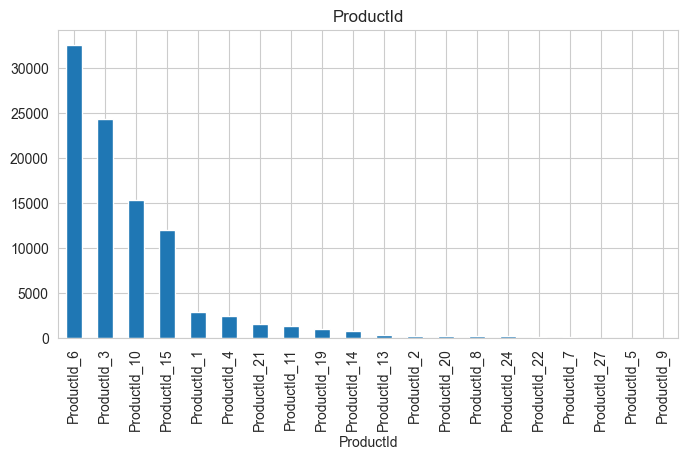

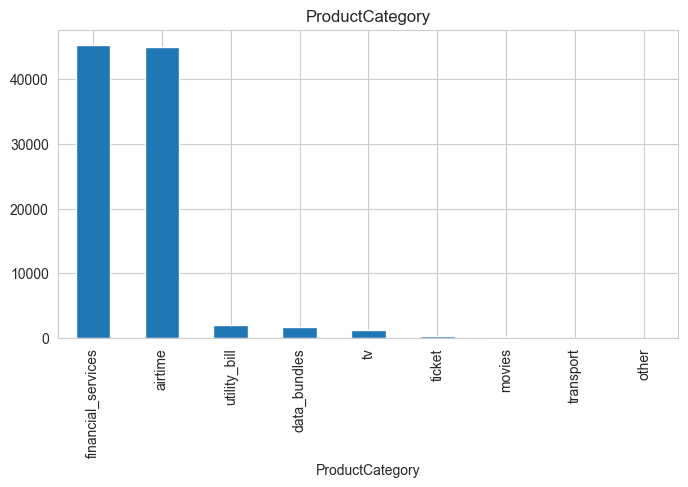

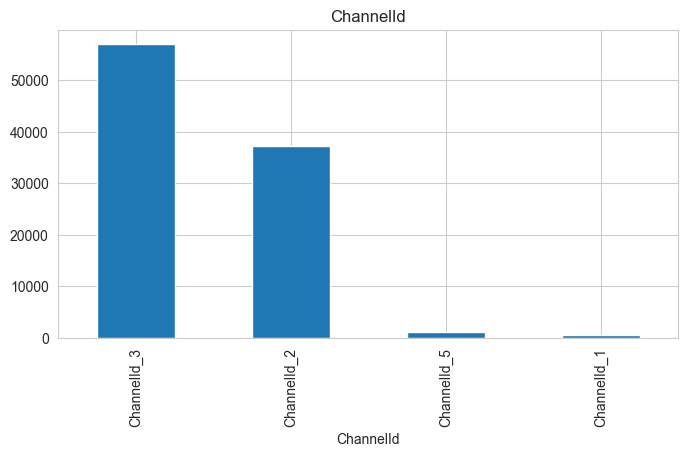

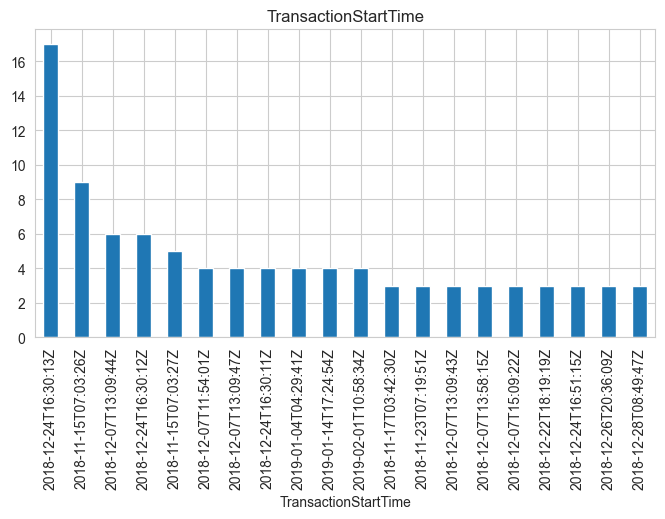

In [12]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(col)
    plt.show()

### Interpretation

The category frequencies are not evenly distributed.

Key observations:

- Dominant categories.
- Rare categories.
- Potential class imbalance.

Implication:
Categorical encoding techniques should account for highly imbalanced categories.

## Fraud Analysis

In [13]:
df["FraudResult"].value_counts(normalize=True)*100

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64

Fraudulent transactions account for only approximately 0.2% of all observations, indicating a highly imbalanced target distribution. This imbalance highlights the rarity of fraudulent activity and suggests that future fraud-related modeling tasks would require specialized evaluation metrics and potentially class-balancing techniques.

<Axes: xlabel='FraudResult', ylabel='count'>

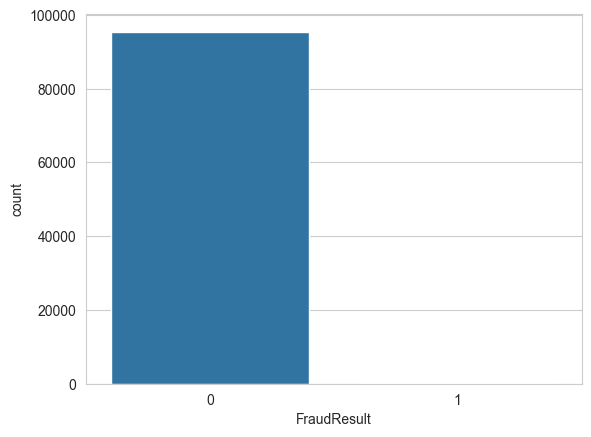

In [14]:
sns.countplot(data=df, x="FraudResult")

### Interpretation

The target distribution appears highly imbalanced.

Key observations:

- Majority of transactions are non-fraudulent.
- Fraudulent transactions represent only a small percentage of observations.

Implication:
Future classification models may require techniques such as class weighting, resampling, or specialized evaluation metrics.

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and highlights potential redundancy or multicollinearity.

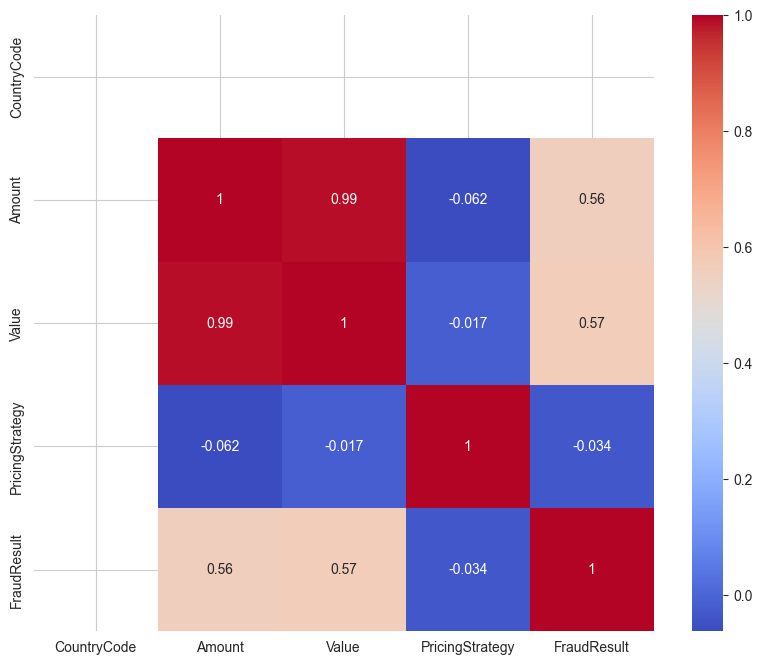

In [15]:
try:
    corr = df.select_dtypes(include=np.number).corr()
except Exception as e:
    print(f"Correlation computation failed: {e}")

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

### Interpretation

Transaction Amount and Value exhibit an almost perfect positive correlation (0.99), indicating that both variables capture nearly identical information. Retaining both features may introduce redundancy during modeling.

FraudResult shows a moderate positive relationship with both Amount and Value, suggesting that higher-value transactions may be associated with increased fraud risk.

PricingStrategy demonstrates virtually no linear relationship with FraudResult, indicating limited standalone predictive power.

## Transaction Time Analysis

Customer transaction behavior often varies over time. This section explores transaction patterns across hours, days, and months to identify potentially predictive temporal features.

In [16]:
try:
    df["TransactionStartTime"] = pd.to_datetime(
        df["TransactionStartTime"]
    )
except Exception as e:
    print(f"Datetime conversion failed: {e}")

In [17]:
df["hour"] = df["TransactionStartTime"].dt.hour
df["day"] = df["TransactionStartTime"].dt.day
df["month"] = df["TransactionStartTime"].dt.month

### Visualization

<Axes: xlabel='hour', ylabel='count'>

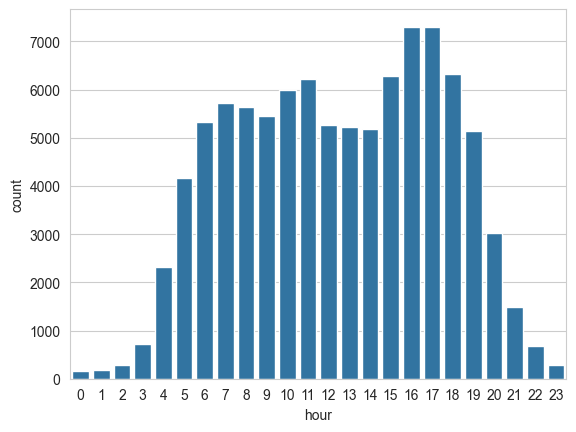

In [18]:
sns.countplot(x=df["hour"])

<Axes: xlabel='month', ylabel='count'>

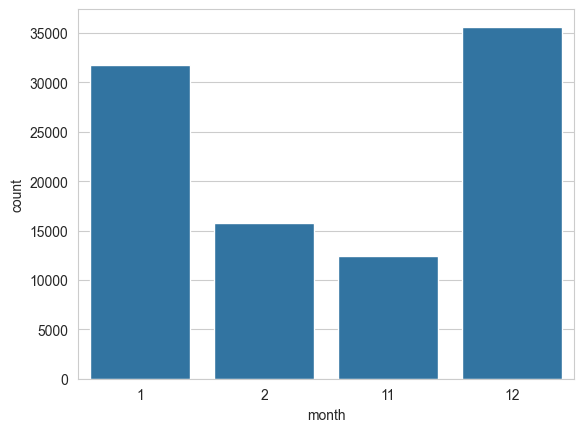

In [19]:
sns.countplot(x=df["month"])

# Key Insights

## Insight 1: The dataset is complete and requires minimal data cleaning

The dataset contains 95,662 transaction records across 16 features with no missing values detected. This reduces preprocessing complexity and allows feature engineering efforts to focus on extracting predictive signals rather than addressing data quality issues.

## Insight 2: Transaction amounts are highly skewed with significant outliers

Transaction Amount and Value distributions exhibit strong right skewness, with a small number of extremely large transactions stretching the distribution. This suggests that scaling, standardization, or logarithmic transformations may be necessary to improve model stability and performance.

## Insight 3: CountryCode provides no predictive value

All transactions originate from the same CountryCode (256), resulting in zero variance. Since the feature cannot differentiate between customers or transactions, it is unlikely to contribute useful information to downstream models and should be excluded from modeling.

## Insight 4: Transaction Amount and Value contain highly redundant information

Correlation analysis revealed an almost perfect positive correlation between Amount and Value (≈ 0.99). This indicates that both features capture nearly identical information, and feature selection techniques should be considered to reduce redundancy and potential multicollinearity.

## Insight 5: Fraudulent transactions are extremely rare

Fraudulent transactions account for only approximately 0.2% of all observations, demonstrating a highly imbalanced distribution. While fraud detection is not the primary objective of this project, this finding highlights the importance of carefully evaluating class distributions when constructing proxy risk labels and training classification models.

## Conclusion

The exploratory analysis revealed a high-quality dataset with no missing values, significant skewness in transaction-related variables, and several opportunities for feature engineering. Customer-level aggregation, temporal feature extraction, and RFM-based behavioral analysis are expected to provide the strongest signals for constructing a proxy credit risk target and developing predictive credit scoring models.




In [3]:
# EDA - Dataset Overview
import pandas as pd

print("Shape:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe:")
display(df.describe(include="all"))

Shape: (95662, 60)


,num__Amount,num__Value,num__PricingStrategy,num__FraudResult,num__total_transaction_amount,num__avg_transaction_amount,num__transaction_count,num__std_transaction_amount,num__max_transaction_amount,num__min_transaction_amount,...,cat__ProductCategory_other,cat__ProductCategory_ticket,cat__ProductCategory_transport,cat__ProductCategory_tv,cat__ProductCategory_utility_bill,cat__ChannelId_ChannelId_1,cat__ChannelId_ChannelId_2,cat__ChannelId_ChannelId_3,cat__ChannelId_ChannelId_5,is_high_risk
0,-0.046371,-0.072291,-0.349252,-0.044962,0.170118,-0.067623,-0.311831,-0.167016,-0.193027,0.163927,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.054643,-0.080251,-0.349252,-0.044962,0.170118,-0.067623,-0.311831,-0.167016,-0.193027,0.163927,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,-0.050426,-0.076352,-0.349252,-0.044962,0.165122,-0.072568,-0.444993,-0.201209,-0.229522,0.283780,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,0.107717,0.096648,-0.349252,-0.044962,0.175567,-0.008155,-0.404020,-0.008243,-0.043301,0.054969,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
4,-0.059704,-0.075183,-0.349252,-0.044962,0.175567,-0.008155,-0.404020,-0.008243,-0.043301,0.054969,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 60 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   num__Amount                              95662 non-null  float64
 1   num__Value                               95662 non-null  float64
 2   num__PricingStrategy                     95662 non-null  float64
 3   num__FraudResult                         95662 non-null  float64
 4   num__total_transaction_amount            95662 non-null  float64
 5   num__avg_transaction_amount              95662 non-null  float64
 6   num__transaction_count                   95662 non-null  float64
 7   num__std_transaction_amount              95662 non-null  float64
 8   num__max_transaction_amount              95662 non-null  float64
 9   num__min_transaction_amount              95662 non-null  float64
 10  num__transaction_hour                  

,num__Amount,num__Value,num__PricingStrategy,num__FraudResult,num__total_transaction_amount,num__avg_transaction_amount,num__transaction_count,num__std_transaction_amount,num__max_transaction_amount,num__min_transaction_amount,...,cat__ProductCategory_other,cat__ProductCategory_ticket,cat__ProductCategory_transport,cat__ProductCategory_tv,cat__ProductCategory_utility_bill,cat__ChannelId_ChannelId_1,cat__ChannelId_ChannelId_2,cat__ChannelId_ChannelId_3,cat__ChannelId_ChannelId_5,is_high_risk
count,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,9.566200e+04,...,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000,95662.000000
mean,2.198581e-17,2.614529e-17,9.982746e-17,2.971055e-17,-9.507377e-18,3.446424e-17,9.507377e-18,3.802951e-17,3.802951e-17,4.753689e-17,...,0.000021,0.002258,0.000261,0.013370,0.020071,0.005624,0.388252,0.595168,0.010955,0.115082
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,...,0.004572,0.047464,0.016164,0.114854,0.140243,0.074782,0.487355,0.490862,0.104093,0.319123
min,-8.164376e+00,-8.039691e-02,-3.078062e+00,-4.496219e-02,-4.646278e+00,-5.038543e+00,-4.461315e-01,-2.012087e-01,-6.047713e-01,-2.151864e+01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-5.488653e-02,-7.817959e-02,-3.492524e-01,-4.496219e-02,1.678282e-01,-6.368859e-02,-4.108492e-01,-1.658117e-01,-2.117423e-01,1.639271e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-4.637114e-02,-7.229109e-02,-3.492524e-01,-4.496219e-02,1.743188e-01,-5.187601e-02,-3.414227e-01,-1.354114e-01,-1.930267e-01,1.639271e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,-3.177332e-02,-3.980285e-02,-3.492524e-01,-4.496219e-02,1.975924e-01,-3.078067e-02,-1.365574e-01,-8.505814e-02,-1.275218e-01,2.510932e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,8.007129e+01,8.016556e+01,2.379557e+00,2.224091e+01,3.992660e+00,1.003127e+02,4.208861e+00,3.699897e+01,1.826062e+01,4.385593e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# Missing values analysis
missing = df.isnull().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100
missing = missing.sort_values("missing_pct", ascending=False)

display(missing)

,missing_count,missing_pct
num__Amount,0,0.0
num__Value,0,0.0
num__PricingStrategy,0,0.0
num__FraudResult,0,0.0
num__total_transaction_amount,0,0.0
num__avg_transaction_amount,0,0.0
num__transaction_count,0,0.0
num__std_transaction_amount,0,0.0
num__max_transaction_amount,0,0.0
num__min_transaction_amount,0,0.0


In [ ]:
from xverse.transformer import WOE

woe = WOE()

# Example: fit WoE on training data only
X_train_woe = woe.fit_transform(X_train, y_train)
X_test_woe = woe.transform(X_test)

In [2]:
import pandas as pd
import numpy as np

def calc_iv(df, feature, target, bins=10):
    """Calculate Information Value (IV) for a given feature."""
    df = df[[feature, target]].copy()
    df[feature] = pd.qcut(df[feature], bins, duplicates='drop')
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped['non_event'] = grouped['count'] - grouped['sum']
    grouped['event_rate'] = grouped['sum'] / grouped['sum'].sum()
    grouped['non_event_rate'] = grouped['non_event'] / grouped['non_event'].sum()
    grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
    grouped['iv'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
    return grouped['iv'].sum()

def iv_ranking(df, target):
    """Generate IV ranking table for all numeric features."""
    iv_table = []
    for col in df.select_dtypes(include=[np.number]).columns:
        if col != target:
            iv = calc_iv(df, col, target)
            iv_table.append((col, iv))
    iv_df = pd.DataFrame(iv_table, columns=['Feature', 'IV']).sort_values('IV', ascending=False)
    iv_df['Predictive Power'] = pd.cut(
        iv_df['IV'],
        bins=[-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
        labels=['Not useful', 'Weak', 'Medium', 'Strong', 'Suspiciously good']
    )
    return iv_df

# 🔹 Replace this with your actual dataset path
df = pd.read_csv("../data/processed/model_data.csv")

# 🔹 Replace 'default' with your target column name
iv_results = iv_ranking(df, target='is_high_risk')

print(iv_results)


C:\Users\sumex\AppData\Local\Temp\ipykernel_13468\2780902728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\sumex\AppData\Local\Temp\ipykernel_13468\2780902728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\sumex\AppData\Local\Temp\ipykernel_13468\2780902728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

                                    Feature        IV   Predictive Power
6                    num__transaction_count       inf  Suspiciously good
12                   num__transaction_month  1.729474  Suspiciously good
4             num__total_transaction_amount  0.831489  Suspiciously good
9               num__min_transaction_amount  0.367803             Strong
7               num__std_transaction_amount  0.278257             Medium
8               num__max_transaction_amount  0.268356             Medium
11                     num__transaction_day  0.228373             Medium
5               num__avg_transaction_amount  0.116704             Medium
14                         num__day_of_week  0.035727               Weak
0                               num__Amount  0.032331               Weak
10                    num__transaction_hour  0.023726               Weak
1                                num__Value  0.018508         Not useful
2                      num__PricingStrategy  0.0033

C:\Users\sumex\AppData\Local\Temp\ipykernel_13468\2780902728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\sumex\AppData\Local\Temp\ipykernel_13468\2780902728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
C:\Users\sumex\AppData\Local\Temp\ipykernel_13468\2780902728.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from xverse.transformer import WOE

class WoETransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.woe = WOE()

    def fit(self, X, y):
        self.woe.fit(X, y)
        return self

    def transform(self, X):
        return self.woe.transform(X)

In [ ]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline(steps=[
    ("woe", WoETransformer()),
    ("classifier", best_model)
])

In [ ]:
import mlflow
import mlflow.sklearn

with mlflow.start_run() as run:
    
    mlflow.sklearn.log_model(best_model, "model")

    run_id = run.info.run_id
    model_uri = f"runs:/{run_id}/model"

    mlflow.register_model(
        model_uri=model_uri,
        name="credit_risk_model"
    )

    print("Model registered successfully!")

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

client.transition_model_version_stage(
    name="credit_risk_model",
    version=1,
    stage="Production"
)